# Beam v3 with a reduced Krylov Gram factorization

This notebook evaluates the v3 **coordinate hull first, initial-box intersection second** enclosure for the 30,000-dimensional beam at

$$m=500,1000,\ldots,5000.$$

For the monomial Krylov matrix $V_m=[r_0,\widehat A r_0,\ldots,\widehat A^{m-1}r_0]$, define

$$G_m=V_m^T\widehat A V_m=L_mL_m^T,\qquad \widetilde P_m=V_mL_m^{-T}.$$

Then $\widetilde P_m^T\widehat A\widetilde P_m=I$ and the v3 error projector is

$$E_m=I-\widetilde P_m\widetilde P_m^T\widehat A.$$

The literal power basis is not formed: even after Jacobi scaling its columns become numerically collinear long before $m=500$. A twice-reorthogonalized Arnoldi/Lanczos basis $Q_m$ is used instead. Since $Q_m=V_mR_m$ for a nonsingular basis change in exact arithmetic,

$$Q_m(Q_m^T\widehat A Q_m)^{-1}Q_m^T=V_m(V_m^T\widehat A V_m)^{-1}V_m^T,$$

so the projector and enclosure are unchanged while the reduced Cholesky factorization remains numerically meaningful. The full matrix $\widehat A$ is never factorized or solved.

The dense error projector cannot be formed for all 30,000 rows. As in `systeam_beam_v3.ipynb`, exact hulls are evaluated on a deterministic union of evenly sampled coordinates and evenly sampled coordinates congruent to 1 modulo 3.

In [1]:
from pathlib import Path
from time import perf_counter
import gc
import pickle

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import cholesky, solve_triangular
from scipy.sparse import csr_matrix, diags


pickle_path = Path("wing_bsm_30k.pkl")
with pickle_path.open("rb") as file:
    K_full, F_full, U_full, B0_1_full, B0_2_full = pickle.load(file)

A_full = csr_matrix(K_full)
A = A_full[3:, 3:].tocsr()
b = np.asarray(F_full[3:], dtype=float).copy()
stored_solution = np.asarray(U_full[3:], dtype=float).copy()
initial_box = np.asarray(B0_1_full[3:], dtype=float).copy()
if not np.array_equal(B0_1_full[3:], B0_2_full[3:]):
    raise ValueError("The two beam boxes differ after removing the BC coordinates.")

del K_full, F_full, U_full, B0_1_full, B0_2_full, A_full
gc.collect()

n = b.size
if A.shape != (n, n):
    raise ValueError(f"Expected A to have shape {(n, n)}, got {A.shape}.")
if np.any(initial_box[:, 0] > initial_box[:, 1]):
    raise ValueError("The initial box has inverted coordinates.")

diagonal = A.diagonal()
if np.any(diagonal <= 0.0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
inverse_scale = 1.0 / scale
A_hat = (diags(inverse_scale) @ A @ diags(inverse_scale)).tocsr()
b_hat = inverse_scale * b

# The supplied box omits 3,334 entries of the supplied beam displacement.
# Widen it using that supplied vector only; no factorization/solve with A is used.
outside_supplied_box = (stored_solution < initial_box[:, 0]) | (stored_solution > initial_box[:, 1])
effective_box = np.column_stack([
    np.minimum(initial_box[:, 0], stored_solution),
    np.maximum(initial_box[:, 1], stored_solution),
])
lower0 = scale * effective_box[:, 0]
upper0 = scale * effective_box[:, 1]
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)
r0 = b_hat - A_hat @ center0

m_values = np.arange(500, 5001, 500, dtype=int)
max_m = int(m_values[-1])
sample_count_per_family = 80
all_sample = np.unique(np.linspace(0, n - 1, sample_count_per_family).round().astype(int))
mod1 = np.arange(1, n, 3, dtype=int)
mod1_sample = np.unique(
    mod1[np.linspace(0, len(mod1) - 1, sample_count_per_family).round().astype(int)]
)
tracked_indices = np.unique(np.concatenate([all_sample, mod1_sample]))

print(f"system dimension n: {n:,}")
print(f"scaled matrix nonzeros: {A_hat.nnz:,}")
print(f"requested Krylov prefixes: {m_values.tolist()}")
print(f"tracked exact projector rows: {len(tracked_indices)}")
print(f"coordinates widened to contain supplied U: {outside_supplied_box.sum():,}")
print(f"supplied U relative residual: {np.linalg.norm(b - A @ stored_solution) / np.linalg.norm(b):.6e}")
print(f"starting scaled residual norm: {np.linalg.norm(r0):.6e}")

system dimension n: 30,000
scaled matrix nonzeros: 129,994
requested Krylov prefixes: [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
tracked exact projector rows: 134
coordinates widened to contain supplied U: 3,334
supplied U relative residual: 1.254917e-01
starting scaled residual norm: 6.005607e+08


## Stable nested Krylov basis

The following routine constructs one nested Euclidean-orthonormal basis $Q_{m_{\max}}$. Two modified Gram--Schmidt passes prevent the severe loss of independence observed for the unreorthogonalized beam Lanczos vectors. Every prefix $Q_m$ spans $\mathcal K_m(\widehat A,r_0)$.

In [2]:
def stabilized_krylov_basis(A, starting_vector, columns, report_period=500):
    """Return nested Q and A@Q using two-pass modified Gram--Schmidt."""
    starting_vector = np.asarray(starting_vector, dtype=float)
    n = starting_vector.size
    norm0 = float(np.linalg.norm(starting_vector))
    if not np.isfinite(norm0) or norm0 == 0.0:
        raise ValueError("The starting residual must be finite and nonzero.")

    Q = np.empty((n, columns), dtype=float, order="F")
    AQ = np.empty((n, columns), dtype=float, order="F")
    q = starting_vector / norm0
    breakdown_tolerance = 100.0 * np.finfo(float).eps
    started = perf_counter()

    for k in range(columns):
        Aq = A @ q
        Q[:, k] = q
        AQ[:, k] = Aq
        if k + 1 < columns:
            candidate = Aq.copy()
            prefix = Q[:, : k + 1]
            for _ in range(2):
                candidate -= prefix @ (prefix.T @ candidate)
            candidate_norm = float(np.linalg.norm(candidate))
            if not np.isfinite(candidate_norm) or candidate_norm <= breakdown_tolerance:
                raise RuntimeError(f"Krylov breakdown after {k + 1} columns.")
            q = candidate / candidate_norm

        if (k + 1) % report_period == 0 or k + 1 == columns:
            print(f"basis m={k + 1:5,d}/{columns:,}  elapsed={perf_counter() - started:.1f}s")

    return Q, AQ


basis_started = perf_counter()
Q, AQ = stabilized_krylov_basis(A_hat, r0, max_m)
basis_seconds = perf_counter() - basis_started

check_columns = np.unique(np.linspace(0, max_m - 1, 64).round().astype(int))
sample_euclidean_gram = Q[:, check_columns].T @ Q[:, check_columns]
sample_q_orthogonality_error = float(
    np.max(np.abs(sample_euclidean_gram - np.eye(len(check_columns))))
)
print(f"sampled max |Q^T Q-I|: {sample_q_orthogonality_error:.3e}")
print(f"basis construction time: {basis_seconds:.2f} s")

basis m=  500/5,000  elapsed=1.4s


basis m=1,000/5,000  elapsed=5.9s


basis m=1,500/5,000  elapsed=13.5s


basis m=2,000/5,000  elapsed=24.1s


basis m=2,500/5,000  elapsed=37.9s


basis m=3,000/5,000  elapsed=54.8s


basis m=3,500/5,000  elapsed=74.9s


basis m=4,000/5,000  elapsed=98.6s


basis m=4,500/5,000  elapsed=127.4s


basis m=5,000/5,000  elapsed=164.8s
sampled max |Q^T Q-I|: 4.208e-14
basis construction time: 164.78 s


## Reduced Gram Cholesky and $A$-conjugate directions

Only the $5000\times5000$ reduced Gram matrix is factorized. Because the basis and Cholesky factors are nested, the first $m$ columns of the resulting $\widetilde P_{m_{\max}}$ equal the columns obtained by factorizing the leading $m\times m$ Gram matrix separately. Thus all requested prefixes require only one reduced factorization.

In [3]:
gram_started = perf_counter()
G = Q.T @ AQ
gram_symmetry_error = float(np.linalg.norm(G - G.T, ord=np.inf))
G = 0.5 * (G + G.T)
L = cholesky(G, lower=True, check_finite=False)
gram_factor_relative_residual = float(
    np.linalg.norm(G - L @ L.T, ord="fro") / np.linalg.norm(G, ord="fro")
)
gram_seconds = perf_counter() - gram_started

# P^T=L^{-1}Q^T and (A P)^T=L^{-1}(A Q)^T.
transform_started = perf_counter()
P_transpose = solve_triangular(
    L, Q.T, lower=True, check_finite=False, overwrite_b=False
)
del Q
gc.collect()
AP_transpose = solve_triangular(
    L, AQ.T, lower=True, check_finite=False, overwrite_b=False
)
del AQ, G, L
gc.collect()
transform_seconds = perf_counter() - transform_started

sample_a_gram = P_transpose[check_columns] @ AP_transpose[check_columns].T
sample_a_orthogonality_error = float(
    np.max(np.abs(sample_a_gram - np.eye(len(check_columns))))
)
a_norms = np.sum(P_transpose * AP_transpose, axis=1)
max_a_norm_error = float(np.max(np.abs(a_norms - 1.0)))

print(f"unscaled Gram symmetry error (infinity norm): {gram_symmetry_error:.3e}")
print(f"relative Cholesky residual: {gram_factor_relative_residual:.3e}")
print(f"sampled max |P^T A P-I|: {sample_a_orthogonality_error:.3e}")
print(f"max diagonal A-norm error: {max_a_norm_error:.3e}")
print(f"Gram construction/factorization time: {gram_seconds:.2f} s")
print(f"basis transformation time: {transform_seconds:.2f} s")

unscaled Gram symmetry error (infinity norm): 2.180e-14
relative Cholesky residual: 7.019e-17
sampled max |P^T A P-I|: 7.949e-14
max diagonal A-norm error: 1.826e-13
Gram construction/factorization time: 19.57 s
basis transformation time: 17.41 s


## V3 coordinate hull, then intersection

For $[\ell^0,u^0]=c^0+[-d^0,d^0]$, the raw coordinate hull is

$$\widehat x_m\pm |E_m|d^0,\qquad \widehat x_m=c^0+\widetilde P_m\widetilde P_m^Tr_0.$$

Only after that hull has been computed do we intersect it with $[\ell^0,u^0]$. Projector rows are updated in 500-column blocks, so no dense $n\times n$ matrix is stored.

In [4]:
row_count = len(tracked_indices)
projector_rows = np.zeros((row_count, n), dtype=float)
projector_rows[np.arange(row_count), tracked_indices] = 1.0
projected_center = center0[tracked_indices].copy()
center_coefficients = P_transpose @ r0

shape = (len(m_values), row_count)
hull_lower_history = np.empty(shape)
hull_upper_history = np.empty(shape)
lower_history = np.empty(shape)
upper_history = np.empty(shape)
radius_history = np.empty(shape)
empty_counts = np.empty(len(m_values), dtype=int)
enclosure_seconds = np.empty(len(m_values))

previous_m = 0
enclosure_started = perf_counter()
for frame, m in enumerate(m_values):
    block = slice(previous_m, int(m))
    tracked_block = P_transpose[block, tracked_indices].T
    projector_rows -= tracked_block @ AP_transpose[block, :]
    projected_center += tracked_block @ center_coefficients[block]

    projected_radius = np.abs(projector_rows) @ radius0
    hull_lower = projected_center - projected_radius
    hull_upper = projected_center + projected_radius
    contracted_lower = np.maximum(lower0[tracked_indices], hull_lower)
    contracted_upper = np.minimum(upper0[tracked_indices], hull_upper)

    tolerance = 1.0e-12 * np.maximum(1.0, np.maximum(np.abs(contracted_lower), np.abs(contracted_upper)))
    genuinely_empty = contracted_lower > contracted_upper + tolerance
    roundoff_only = (contracted_lower > contracted_upper) & ~genuinely_empty
    midpoint = 0.5 * (contracted_lower[roundoff_only] + contracted_upper[roundoff_only])
    contracted_lower[roundoff_only] = midpoint
    contracted_upper[roundoff_only] = midpoint

    hull_lower_history[frame] = hull_lower
    hull_upper_history[frame] = hull_upper
    lower_history[frame] = contracted_lower
    upper_history[frame] = contracted_upper
    radius_history[frame] = projected_radius
    empty_counts[frame] = np.count_nonzero(genuinely_empty)
    enclosure_seconds[frame] = perf_counter() - enclosure_started
    previous_m = int(m)
    print(
        f"m={m:5,d}: hull/intersection rows={row_count}, "
        f"empty={empty_counts[frame]}, elapsed={enclosure_seconds[frame]:.1f}s"
    )

initial_width = upper0[tracked_indices] - lower0[tracked_indices]
final_width_history = upper_history - lower_history
shrinkage_history = np.clip(
    100.0 * (1.0 - final_width_history / initial_width[None, :]), 0.0, 100.0
)
contains_supplied_solution = np.all(
    (lower_history <= stored_solution[tracked_indices][None, :] * scale[tracked_indices][None, :])
    & (stored_solution[tracked_indices][None, :] * scale[tracked_indices][None, :] <= upper_history),
    axis=1,
)

quantile_levels = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0])
shrinkage_quantiles = np.quantile(shrinkage_history, quantile_levels, axis=1).T
print("\nExact tracked-row shrinkage after hull-then-intersect (%)")
print("m       mean    median     min     p10     p90     max   empty  contains supplied U")
for m, values, q, empty, contains in zip(
    m_values, shrinkage_history, shrinkage_quantiles, empty_counts, contains_supplied_solution
):
    print(
        f"{m:5d}   {values.mean():6.2f}   {np.median(values):6.2f}"
        f"   {q[0]:6.2f}  {q[1]:6.2f}  {q[5]:6.2f}  {q[6]:6.2f}"
        f"   {empty:5d}  {str(bool(contains)):>19s}"
    )

m=  500: hull/intersection rows=134, empty=0, elapsed=0.1s
m=1,000: hull/intersection rows=134, empty=0, elapsed=0.1s
m=1,500: hull/intersection rows=134, empty=0, elapsed=0.2s


m=2,000: hull/intersection rows=134, empty=0, elapsed=0.2s


m=2,500: hull/intersection rows=134, empty=0, elapsed=0.3s
m=3,000: hull/intersection rows=134, empty=0, elapsed=0.3s
m=3,500: hull/intersection rows=134, empty=0, elapsed=0.4s


m=4,000: hull/intersection rows=134, empty=0, elapsed=0.4s


m=4,500: hull/intersection rows=134, empty=0, elapsed=0.5s
m=5,000: hull/intersection rows=134, empty=0, elapsed=0.5s

Exact tracked-row shrinkage after hull-then-intersect (%)
m       mean    median     min     p10     p90     max   empty  contains supplied U
  500     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 1000     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 1500     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 2000     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 2500     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 3000     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 3500     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 4000     0.00     0.00     0.00    0.00    0.00    0.00       0                 True
 4500     0.00     0.00     0.00    0.00    0.00   

## Save results and plots

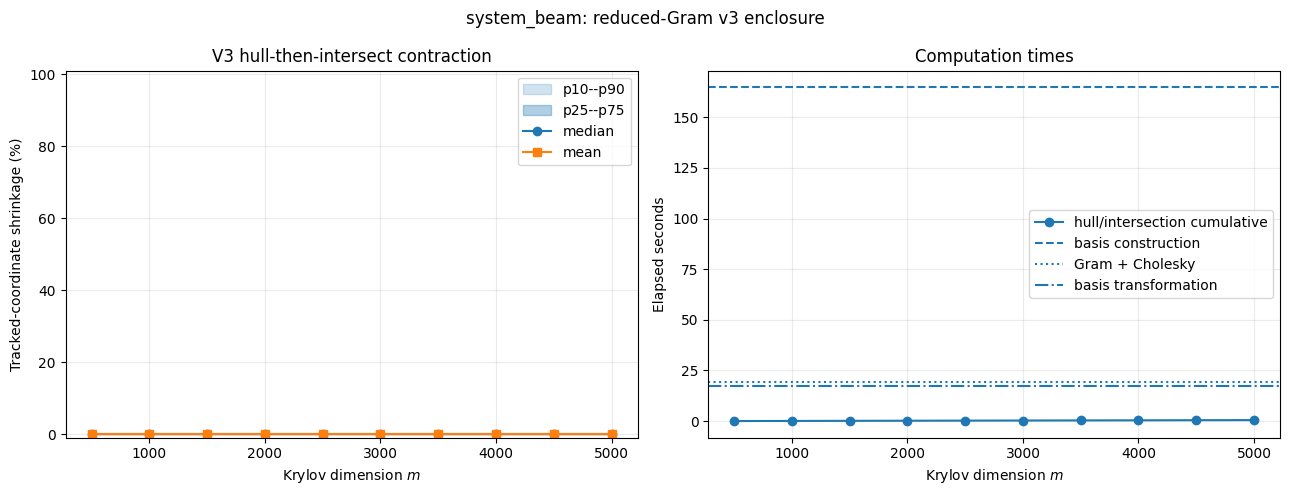

saved system_beam_krylov_gram_v3_results/tracked_hull_intersection_results.npz
saved system_beam_krylov_gram_v3_results/shrinkage_and_timing.png


In [5]:
results_directory = Path("system_beam_krylov_gram_v3_results")
results_directory.mkdir(exist_ok=True)
data_path = results_directory / "tracked_hull_intersection_results.npz"
np.savez_compressed(
    data_path,
    n=n,
    m_values=m_values,
    tracked_indices=tracked_indices,
    lower_history=lower_history / scale[tracked_indices][None, :],
    upper_history=upper_history / scale[tracked_indices][None, :],
    hull_lower_history=hull_lower_history / scale[tracked_indices][None, :],
    hull_upper_history=hull_upper_history / scale[tracked_indices][None, :],
    shrinkage_history=shrinkage_history,
    shrinkage_quantiles=shrinkage_quantiles,
    quantile_levels=quantile_levels,
    empty_counts=empty_counts,
    contains_supplied_solution=contains_supplied_solution,
    basis_seconds=basis_seconds,
    gram_seconds=gram_seconds,
    transform_seconds=transform_seconds,
    enclosure_seconds=enclosure_seconds,
    sample_q_orthogonality_error=sample_q_orthogonality_error,
    sample_a_orthogonality_error=sample_a_orthogonality_error,
    max_a_norm_error=max_a_norm_error,
    gram_symmetry_error=gram_symmetry_error,
    gram_factor_relative_residual=gram_factor_relative_residual,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].fill_between(
    m_values, shrinkage_quantiles[:, 1], shrinkage_quantiles[:, 5],
    alpha=0.20, color="tab:blue", label="p10--p90",
)
axes[0].fill_between(
    m_values, shrinkage_quantiles[:, 2], shrinkage_quantiles[:, 4],
    alpha=0.35, color="tab:blue", label="p25--p75",
)
axes[0].plot(m_values, shrinkage_quantiles[:, 3], marker="o", label="median")
axes[0].plot(m_values, shrinkage_history.mean(axis=1), marker="s", label="mean")
axes[0].set(
    xlabel="Krylov dimension $m$", ylabel="Tracked-coordinate shrinkage (%)",
    title="V3 hull-then-intersect contraction", ylim=(-1, 101),
)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(m_values, enclosure_seconds, marker="o", label="hull/intersection cumulative")
axes[1].axhline(basis_seconds, linestyle="--", label="basis construction")
axes[1].axhline(gram_seconds, linestyle=":", label="Gram + Cholesky")
axes[1].axhline(transform_seconds, linestyle="-.", label="basis transformation")
axes[1].set(
    xlabel="Krylov dimension $m$", ylabel="Elapsed seconds",
    title="Computation times",
)
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.suptitle("system_beam: reduced-Gram v3 enclosure")
fig.tight_layout()
figure_path = results_directory / "shrinkage_and_timing.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {data_path}")
print(f"saved {figure_path}")